In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


In [15]:

# Load and prepare
dataset = pd.read_csv("Salary_Data.csv")
X = dataset[["YearsExperience"]]
y = dataset["Salary"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Train model with custom parameters
model = DecisionTreeRegressor(
    max_depth=3,           # Limit tree depth
    min_samples_split=5,   # Minimum samples to split node
    min_samples_leaf=2,    # Minimum samples in leaf node
    random_state=0
)

In [16]:

model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")



MAE: 5217.4524
R² Score: 0.9488
RMSE: 6798.9453


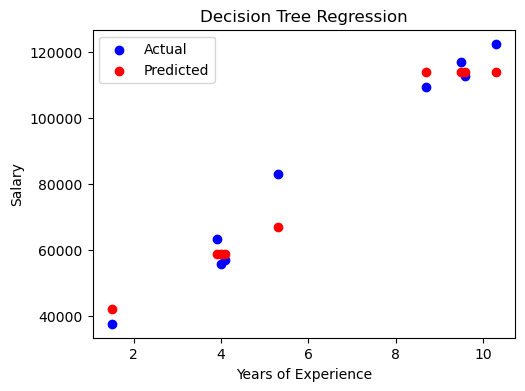

In [17]:

# Plot predictions vs actual
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.scatter(X_test, y_pred, color='red', label='Predicted')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Decision Tree Regression')
plt.legend()

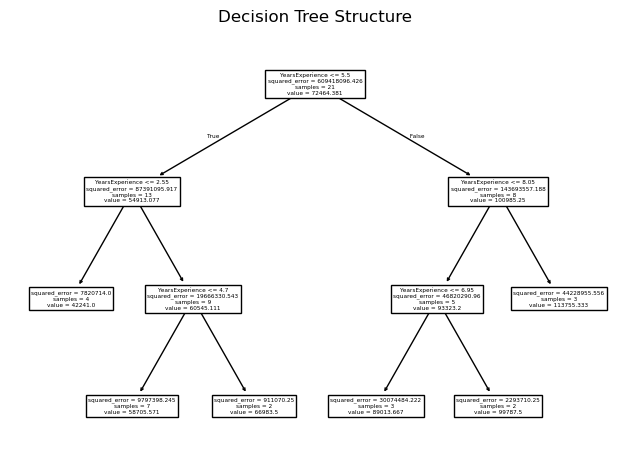

In [20]:

# Plot tree structure
plot_tree(model, feature_names=['YearsExperience'])
plt.title('Decision Tree Structure')

plt.tight_layout()
plt.show()